# 01 EDA

Цель: первично проверить данные, целевую переменную и базовые зависимости

In [12]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..')
raw_path = ROOT / 'data' / 'raw' / 'electricity_load.csv'
df = pd.read_csv(raw_path)
df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [13]:
print('shape:', df.shape)
print('columns:', len(df.columns))
print('duplicates:', int(df.duplicated().sum()))
df.dtypes.head(10)

shape: (48048, 17)
columns: 17
duplicates: 0


datetime       object
nat_demand    float64
T2M_toc       float64
QV2M_toc      float64
TQL_toc       float64
W2M_toc       float64
T2M_san       float64
QV2M_san      float64
TQL_san       float64
W2M_san       float64
dtype: object

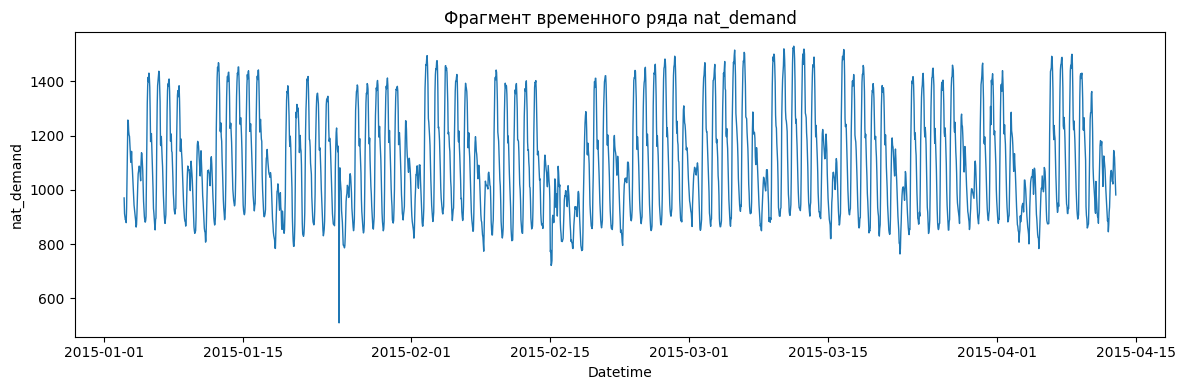

In [14]:
target = 'nat_demand'
dt_col = 'datetime'
tmp = df.copy()
tmp[dt_col] = pd.to_datetime(tmp[dt_col], errors='coerce')
tmp = tmp.dropna(subset=[dt_col]).sort_values(dt_col)

plt.figure(figsize=(12, 4))
plt.plot(tmp[dt_col].iloc[:2400], tmp[target].iloc[:2400], linewidth=1.0)
plt.title('Фрагмент временного ряда nat_demand')
plt.xlabel('Datetime')
plt.ylabel('nat_demand')
plt.tight_layout()
plt.show()

Дальнейшая подготовка и сохранение итоговых артефактов выполняется скриптом `src/preprocessing.py`

In [15]:
num_cols = df.select_dtypes(include='number').columns
print('numeric columns:', len(num_cols))
print(df[num_cols].describe().T[['mean', 'std', 'min', 'max']].head(8))

numeric columns: 16
                   mean         std        min          max
nat_demand  1182.868647  192.068896  85.192500  1754.882000
T2M_toc       27.399111    1.675462  22.953455    35.039575
QV2M_toc       0.018313    0.001607   0.012054     0.022690
TQL_toc        0.079979    0.065589   0.000000     0.521240
W2M_toc       13.391049    7.295502   0.008979    39.229726
T2M_san       26.921023    3.018129  19.765222    39.063440
QV2M_san       0.017844    0.001889   0.010247     0.022165
TQL_san        0.106265    0.086293   0.000009     0.484985


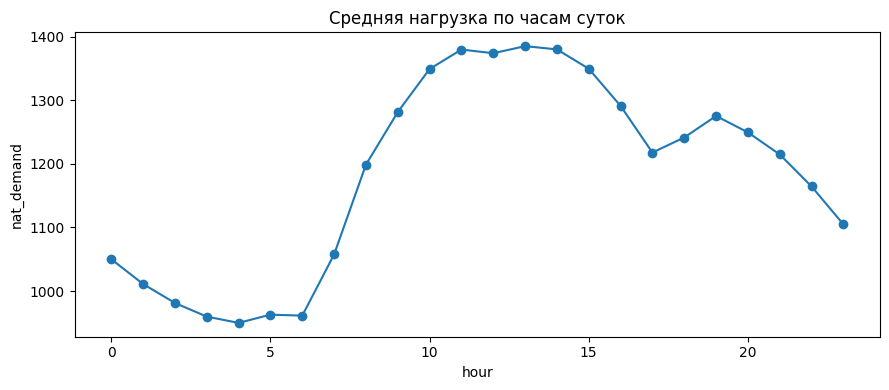

In [16]:
tmp['hour'] = tmp[dt_col].dt.hour
hour_profile = tmp.groupby('hour')[target].mean()

plt.figure(figsize=(9, 4))
plt.plot(hour_profile.index, hour_profile.values, marker='o')
plt.title('Средняя нагрузка по часам суток')
plt.xlabel('hour')
plt.ylabel('nat_demand')
plt.tight_layout()
plt.show()

In [17]:
df2 = df[['datetime', 'nat_demand']].copy()
df2['datetime'] = pd.to_datetime(df2['datetime'], errors='coerce')
df2 = df2.dropna(subset=['datetime'])

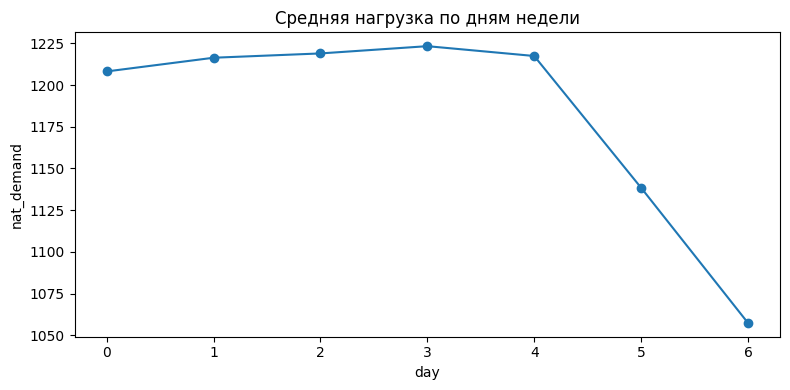

In [18]:
df2['day_of_week'] = df2['datetime'].dt.dayofweek
week_profile = df2.groupby('day_of_week')['nat_demand'].mean()

plt.figure(figsize=(8, 4))
plt.plot(week_profile.index, week_profile.values, marker='o')
plt.title('Средняя нагрузка по дням недели')
plt.xlabel('day')
plt.ylabel('nat_demand')
plt.tight_layout()
plt.show()

- У нагрузки есть выраженная суточная сезонность: часы пиков и провалов повторяются
- Недельный профиль показывает различие между буднями и выходными
- На временном графике заметны редкие резкие пики
- Корреляционная структура подтверждает, что лаговые признаки информативнее части погодных факторов

Вывод по EDA: у нагрузки есть выраженная суточная и недельная сезонность, а лаговые признаки должны быть полезны для прогноза

Проверка, что парсер корректно читает исходный файл и возвращает ожидаемую структуру

In [21]:
import sys
from pathlib import Path

ROOT = Path('..')
sys.path.append(str((ROOT / 'src').resolve()))

from parse_data import parse_csv_dataset

raw_path = ROOT / 'data' / 'raw' / 'electricity_load.csv'
parsed_df = parse_csv_dataset(raw_path)
print('shape:', parsed_df.shape)
print('columns:', parsed_df.columns.tolist()[:10], '...')
print(parsed_df.head(3))

shape: (48048, 17)
columns: ['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san'] ...
             datetime  nat_demand    T2M_toc  QV2M_toc   TQL_toc    W2M_toc  \
0 2015-01-03 01:00:00    970.3450  25.865259  0.018576  0.016174  21.850546   
1 2015-01-03 02:00:00    912.1755  25.899255  0.018653  0.016418  22.166944   
2 2015-01-03 03:00:00    900.2688  25.937280  0.018768  0.015480  22.454911   

     T2M_san  QV2M_san   TQL_san    W2M_san    T2M_dav  QV2M_dav   TQL_dav  \
0  23.482446  0.017272  0.001855  10.328949  22.662134  0.016562  0.096100   
1  23.399255  0.017265  0.001327  10.681517  22.578943  0.016509  0.087646   
2  23.343530  0.017211  0.001428  10.874924  22.531030  0.016479  0.078735   

    W2M_dav  Holiday_ID  holiday  school  
0  5.364148           0        0       0  
1  5.572471           0        0       0  
2  5.871184           0        0       0  
